**딥러닝(Deep Learning: DL)** 은 다수 은닉층(hidden layer)을 가진 인공신경망을 적용한 기법

딥러닝의 기본 엔진으로는 Tensorflow을 주로 사용. 간편한 인터페이스를 위한 엔진으로는 Keras가 존재.

# 6.1. MF를 신경망으로 변환하기

먼저 은닉층이 없는 신경망 모형을 Keras로 구현해볼 예정. 은닉층이 없는 신경망 모델은 MF 알고리즘과 기본적으로는 같은 모형.

![딥러닝](../static/img_6.png)

## One-Hot Representation

### One-Hot Representation이란?

One-Hot Representation은 여러 개의 범주(category) 중 딱 하나만 1이고 나머지는 전부 0인 벡터 표현.

예를 들어,
	•	사용자 수 = 5명
	•	user_id = 2번

이면 벡터는: $\text{user}_2 = [0, 1, 0, 0, 0]$

### 추천 시스템에서 왜 One-Hot이 등장하는 이유

신경망은 숫자 벡터만 입력으로 받을 수 있기 때문.
- user_id = 2
- item_id = 10

이런 정수 ID 자체에는 의미가 없음 (2가 1보다 두 배 더 중요한 게 아니기에)

그래서 ID → 벡터로 바꿔주는 과정이 필요

→ 그 가장 원초적인 방법이 One-Hot Encoding

### One-Hot Representation Layer의 역할

추천 모델 입력 흐름

```
user_id ─▶ One-Hot Vector
item_id ─▶ One-Hot Vector
```

이 단계에서:
- 사용자 ID → 사용자 공간의 좌표
- 아이템 ID → 아이템 공간의 좌표


## MF to Deep Learning

### 기존 Matrix Factorization(MF) 요약

MF: 사용자 벡터와 아이템 벡터를 곱해서 평점을 예측한다

수식으로는 아래와 같음.

$$
\hat r_{ui} = \mathbf{p}_u^\top \mathbf{q}_i
$$
$$
\mathbf{p}_u: 사용자 임베딩 벡터, \quad
\mathbf{q}_i: 아이템 임베딩 벡터
$$

### 이걸 “신경망 관점”으로 보면?

여기서 관점을 살짝만 바꿔보자.

👉 사용자 ID, 아이템 ID는 사실상 입력값
- 입력: (user_id, item_id)
- 출력: 예측 평점

그럼 중간에서 무슨 일이 일어나지?

👉 Embedding lookup = 신경망의 첫 번째 레이어
	•	user_id → 사용자 embedding vector
	•	item_id → 아이템 embedding vector

이건 딥러닝에서 말하는 Embedding Layer랑 완전히 같다.

### MF는 사실 이런 “초간단 신경망”이다

<pre>
user_id ──▶ [User Embedding] ──┐
                               ├─ dot product ─▶ predicted rating
item_id ──▶ [Item Embedding] ──┘
</pre>


🔑 여기서 중요한 포인트:
- Embedding = 학습 가능한 파라미터 (가중치)
- dot product = 고정된 연산 (비선형 없음)
- hidden layer 없음

👉 그래서 MF는
“Hidden layer가 없는 신경망” 또는 “선형 모델” 로 볼 수 있다.

### Deep Learning으로 바꾼다는 건, 뭘 바꾸는 걸까?

**MF의 한계**
- 사용자와 아이템 관계가 선형(linear) 이라고 가정
- “A와 B가 동시에 좋을 때만 점수가 튄다” 같은 복잡한 패턴 표현 불가

→ hookup 점수(내적) 말고 신경망이 직접 관계를 학습하게 하자.

### MF → Neural Network 로의 핵심 변화

(1) dot product를 버린다 (또는 약화시킨다)

기존:
$\hat r_{ui} = \mathbf{p}_u^\top \mathbf{q}_i$

변경:
1. 사용자 벡터 + 아이템 벡터를 붙이고(concat)
2. MLP(다층 신경망)에 넣는다

$\hat r_{ui} = f_{\text{NN}}([\mathbf{p}_u ; \mathbf{q}_i])$

⸻

(2) 구조적으로 보면 이렇게 바뀐다

![MF_to_network](../static/img_7.png)

<pre>
user_id ─▶ Embedding ─┐  
                      ├─ concat ─▶ Dense ─▶ Dense ─▶ rating
item_id ─▶ Embedding ─┘  
</pre>

이제는:
- 관계가 비선형
- 복잡한 interaction 학습 가능
- feature 조합 자동 학습



# 6.2. Keras로 MF 구현하기

In [ ]:
pip install tensorflow  # pyright: ignore

In [24]:
# csv 파일에서 불러오기
import pandas as pd

# train set과 test set을 나누기 위한 라이브러리
from sklearn.model_selection import train_test_split

# 필요한 tensorflow 모듈들을 가져온다.
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
from tensorflow.keras import layers  # pyright: ignore[reportMissingImports]
from tensorflow.keras.models import Model  # pyright: ignore[reportMissingImports]
from tensorflow.keras.layers import Input, Embedding, Dot, Add, Flatten  # pyright: ignore[reportMissingImports]
from tensorflow.keras import regularizers  # pyright: ignore[reportMissingImports]
from tensorflow.keras import optimizers  # pyright: ignore[reportMissingImports]
from tensorflow.keras.regularizers import l2 # pyright: ignore[reportMissingImports]
from tensorflow.keras.optimizers import SGD # pyright: ignore[reportMissingImports]


# DataFrame 형태로 데이터를 읽어온다.
r_cols = ['user_id','movie_id','rating','timestamp']
ratings = pd.read_csv(Path.cwd().parent / 'data' / 'u.data',
                      names=r_cols,
                      sep='\t',
                      encoding='latin-1')

ratings_train,ratings_test = train_test_split(ratings,
                                              test_size=0.2,
                                              shuffle=True,
                                              random_state=2021)



In [25]:
K = 200

mu = ratings_train.rating.mean()

M = ratings.user_id.max() + 1
N = ratings.movie_id.max() + 1

def RMSE(y_true ,y_pred):
  return tf.sqrt(tf.reduce_mean(tf.square(y_true-y_pred)))


In [26]:
user = Input(shape=(1,))
item = Input(shape=(1,))

P_embedding = Embedding(M,K,embeddings_regularizer=l2())(user) # Embedding Layer에 L2 정규화(Weight Decay)를 적용. 과적합 방지용.
Q_embedding = Embedding(N,K,embeddings_regularizer=l2())(item) # Embedding Layer에 L2 정규화(Weight Decay)를 적용. 과적합 방지용.

user_bias = Embedding(M,1,embeddings_regularizer=l2())(user)
item_bias = Embedding(N,1,embeddings_regularizer=l2())(item)

In [27]:
R = layers.dot([P_embedding,Q_embedding],axes=(2,2))

R = layers.add([R,user_bias,item_bias])

R = Flatten()(R)

model = Model(inputs=[user,item],outputs=R)
model.compile(
    loss=RMSE,
    optimizer=SGD(),
    metrics=[RMSE]
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_8         │ (None, 1, 200)    │    188,800 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_9         │ (None, 1, 200)    │    336,600 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dot_1 (Dot)         │ (None, 1, 1)      │          0 │ embedding_8[0][0… │
│                     │                   │            │ embedding_9[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 1, 1)      │        944 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 1, 1)      │      1,683 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1, 1)      │          0 │ dot_1[0][0],      │
│                     │                   │            │ embedding_10[0][… │
│                     │                   │            │ embedding_11[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1)         │          0 │ add_1[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 528,027 (2.01 MB)

 Trainable params: 528,027 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
result = model.fit(
    x = [ratings_train.user_id.values,
         ratings_train.movie_id.values],
    y=ratings_train.rating.values - mu, # 평점에서 평균을 빼서 0 중심으로 만듦 (bias 항에 대한 연산을 편하게 만들기 위함)
    epochs = 60, # 60번 반복
    batch_size=256, # 256개씩 묶어서 학습
    validation_data = (
        [ratings_test.user_id.values,
         ratings_test.movie_id.values],
         ratings_test.rating.values - mu
    )
)

Epoch 1/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 5.2643 - rmse: 1.1273 - val_loss: 5.0003 - val_rmse: 1.1191
Epoch 2/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - loss: 4.7751 - rmse: 1.1272 - val_loss: 4.5414 - val_rmse: 1.1190
Epoch 3/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 4.3435 - rmse: 1.1271 - val_loss: 4.1366 - val_rmse: 1.1189
Epoch 4/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.9629 - rmse: 1.1271 - val_loss: 3.7794 - val_rmse: 1.1189
Epoch 5/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 991us/step - loss: 3.6272 - rmse: 1.1270 - val_loss: 3.4643 - val_rmse: 1.1189
Epoch 6/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 3.3307 - rmse: 1.1271 - val_loss: 3.1864 - val_rmse: 1.1189
Epoch 7/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - loss: 3.0693 - rmse: 1.1269 - val_loss: 2.9411 - val_rmse: 1.1189
Epoch 8/60
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 965us/step - loss: 2.8389 - rmse: 1.1272 - val_loss: 2.7248 - val_rmse: 1.1190
Epoch 9/60
313/313 ━━━━━━━━━━━━━

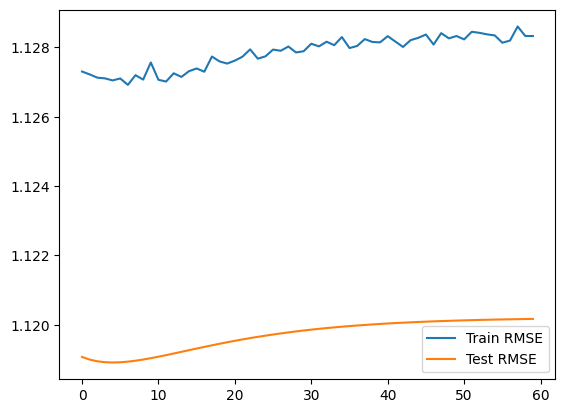

In [ ]:
# Plot RMSE
import matplotlib.pyplot as plt
plt.plot(result.history['rmse'],label="Train RMSE")
plt.plot(result.history['val_rmse'],label='Test RMSE')
plt.legend()
plt.show()

### Q. 결과가 너무 안좋은데...?
# 이는 최근 TensorFlow나 Keras 라이브러리의 버전이 변경되면서, 내부의 초기 weight 설정 방식, 최적화 함수의 기본 learning rate, 정규화의 기본 강도 등이 바뀐 데에 기인할 수 있습니다.
# 특히, SGD 옵티마이저나 Embedding 레이어의 초기화 전략은 버전에 따라 수렴 속도나 안정성에 상당한 차이를 만들 수 있어요. 예전에는 잘 작동했던 코드라도, 라이브러리 업데이트로 인해 수렴하지 않거나, 성능이 오히려 퇴화하는 경우가 실제로 발생합니다.
# 이런 현상은 머신러닝 모델 개발 시 매우 일반적인 경우라, 학습에 대한 플로우정도만 고려해주시면 좋을 것 같습니다.

In [30]:
user_ids = ratings_test.user_id.values[0:6]
movie_ids = ratings_test.movie_id.values[0:6]

predictions = model.predict([user_ids,movie_ids]) + mu

print(ratings_test[0:6])
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
       user_id  movie_id  rating  timestamp
23307      468        51       3  875293386
36679       92       780       3  875660494
36626      555       489       5  879975455
83753      940        69       2  885921265
52604      181      1350       1  878962120
49877      320       195       5  884749255
[[3.5551653]
 [3.4721134]
 [3.5510187]
 [3.5677748]
 [3.189517 ]
 [3.597595 ]]


In [31]:
import numpy as np

def RMSE2(y_true,y_pred):
  return np.sqrt(np.mean((np.array(y_true)-np.array(y_pred))**2))

user_ids = ratings_test.user_id.values
movie_ids = ratings_test.movie_id.values

y_pred = model.predict([user_ids,movie_ids]) + mu

y_pred = np.ravel(y_pred,order='C')

y_true = np.array(ratings_test.rating)

RMSE2(y_true,y_pred)

625/625 ━━━━━━━━━━━━━━━━━━━━ 0s 271us/step


1.0913840424445875

# 6.3. 딥러닝을 적용한 추천 시스템

In [34]:

# csv 파일에서 불러오기
import pandas as pd

# train set과 test set을 나누기 위한 라이브러리
from sklearn.model_selection import train_test_split

# 필요한 tensorflow모듈들을 가져온다.
import tensorflow as tf

from tensorflow.keras import layers  
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Embedding,Dot,Add,Flatten
# layer 구성에 필요한 라이브러리 불러오기
from tensorflow.keras.layers import Dense,Concatenate,Activation
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD,Adamax

# DataFrame 형태로 데이터를 읽어온다.
r_cols = ['user_id','movie_id','rating','timestamp']
ratings = pd.read_csv('../data/u.data',
                      names=r_cols,
                      sep='\t',
                      encoding='latin-1')

ratings_train,ratings_test = train_test_split(ratings,
                                              test_size=0.2,
                                              shuffle=True,
                                              random_state=2021)

# Defining RMSE measure
# y_true, y_pred은 신경망에서 실제값, 예측값을 나타내는 Tensorflow/Keras 표준 변수이다.
def RMSE(y_true, y_pred):
  # Tensorflow의 math 클래스에 미리 정의된
  # 제곱근(sqrt), 평균(reduce_mean), 제곱(square) 함수를 통해 RMSE 계산
  return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

# Variable 초기화
# 잠재요인의 수를 200으로 지정한다.
K = 200
# 전체평균을 계산한다.
mu = ratings_train.rating.mean()
# 사용자 아이디와 영화 아이디의 최대값을 구한다.
# +1를 더해주는 이유는 나중에 bias term의 크기 1를 추가로 고려한 것이다.
M = ratings.user_id.max() + 1
N = ratings.movie_id.max() + 1

########################################################################
# Keras model
# 아래 부분은 앞에서와 동일하게 사용자와 아이템 데이터를 embedding을 통해
# 각각 K개의 노드를 갖는 layer로 변환하고
# 사용자 bias와 아이템 bias를 1개의 노드를 갖는 layer로 변환한다.
user = Input(shape=(1,))
item = Input(shape=(1,))
P_embedding = Embedding(M,K,embeddings_regularizer=l2())(user)
Q_embedding = Embedding(N,K,embeddings_regularizer=l2())(item)

user_bias = Embedding(M,1,embeddings_regularizer=l2())(user)
item_bias = Embedding(N,1,embeddings_regularizer=l2())(item)


P_embedding = Flatten()(P_embedding)
Q_embedding = Flatten()(Q_embedding)
user_bias = Flatten()(user_bias)
item_bias = Flatten()(item_bias)

R = Concatenate()([P_embedding,Q_embedding,user_bias,item_bias])

R = Dense(2048)(R)
R = Activation('linear')(R)

R = Dense(256)(R)
R = Activation('linear')(R)

R = Dense(1)(R)

model = Model(inputs=[user,item],outputs=R)

model.compile(
    loss=RMSE,
    optimizer=SGD(),
    metrics=[RMSE]
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_12        │ (None, 1, 200)    │    188,800 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_13        │ (None, 1, 200)    │    336,600 │ input_layer_9[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_14        │ (None, 1, 1)      │        944 │ input_layer_8[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_15        │ (None, 1, 1)      │      1,683 │ input_layer_9[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 200)       │          0 │ embedding_12[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 200)       │          0 │ embedding_13[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 1)         │          0 │ embedding_14[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 1)         │          0 │ embedding_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 402)       │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ flatten_4[0][0],  │
│                     │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2048)      │    825,344 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 2048)      │          0 │ dense[0][0]       │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │    524,544 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256)       │          0 │ dense_1[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        257 │ activation_1[0][… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,878,172 (7.16 MB)

 Trainable params: 1,878,172 (7.16 MB)

 Non-trainable params: 0 (0.00 B)

In [36]:
# Model fitting
train_user_ids = ratings_train.user_id.values
train_movie_ids = ratings_train.movie_id.values
train_ratings = ratings_train.rating.values

test_user_ids = ratings_test.user_id.values
test_movie_ids = ratings_test.movie_id.values
test_ratings = ratings_test.rating.values

result = model.fit(
    x = [train_user_ids,train_movie_ids],
    y = train_ratings - mu,
    epochs = 65,
    batch_size=512,
    validation_data = (
        [test_user_ids,test_movie_ids],
        test_ratings - mu
    )
)


Epoch 1/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 5.4002 - rmse: 1.1271 - val_loss: 5.2569 - val_rmse: 1.1191
Epoch 2/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.1382 - rmse: 1.1273 - val_loss: 5.0033 - val_rmse: 1.1192
Epoch 3/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.8922 - rmse: 1.1280 - val_loss: 4.7650 - val_rmse: 1.1192
Epoch 4/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.6610 - rmse: 1.1277 - val_loss: 4.5415 - val_rmse: 1.1194
Epoch 5/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.4441 - rmse: 1.1279 - val_loss: 4.3311 - val_rmse: 1.1194
Epoch 6/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.2401 - rmse: 1.1275 - val_loss: 4.1334 - val_rmse: 1.1195
Epoch 7/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.0483 - rmse: 1.1276 - val_loss: 3.9479 - val_rmse: 1.1199
Epoch 8/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.8678 - rmse: 1.1279 - val_loss: 3.7729 - val_rmse: 1.1199
Epoch 9/65
157/157 ━━━━━━━━━━━━━

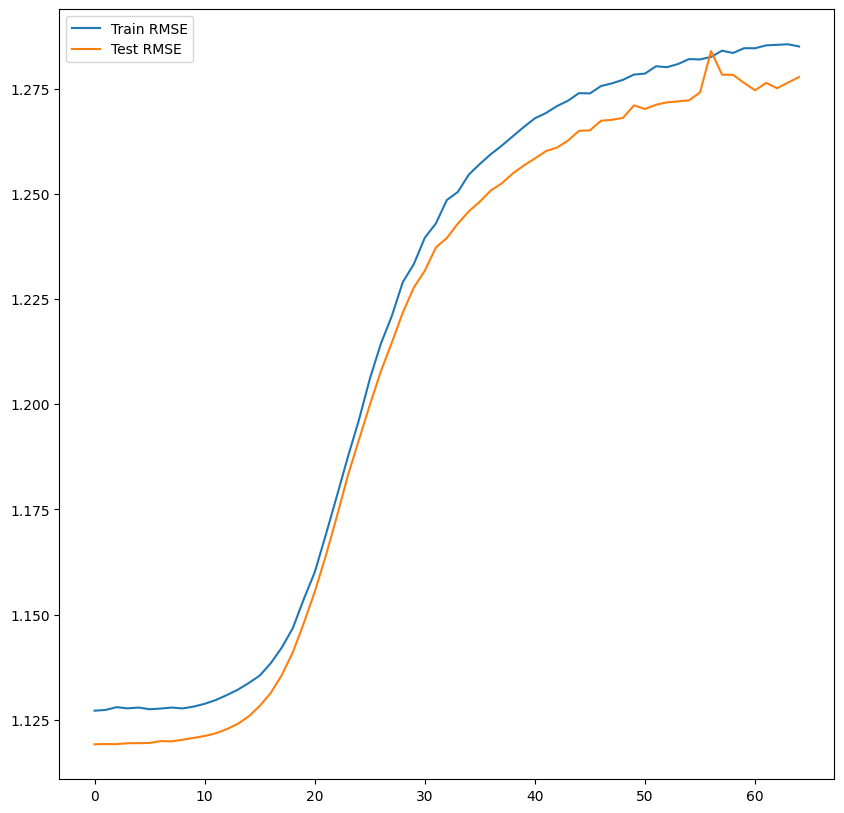

In [37]:
# Plot RMSE
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.plot(result.history['rmse'],label="Train RMSE")
plt.plot(result.history['val_rmse'],label='Test RMSE')
plt.legend()
plt.show()

# 6.4. 딥러닝 모델에 변수 추가하기

In [40]:
# csv 파일에서 불러오기
import pandas as pd

# train set과 test set을 나누기 위한 라이브러리
from sklearn.model_selection import train_test_split

# 필요한 tensorflow모듈들을 가져온다.
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Embedding,Dot,Add,Flatten
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import SGD,Adamax
from tensorflow.keras.layers import Dense,Concatenate,Activation

# Defining RMSE measure
# y_true, y_pred은 신경망에서 실제값, 예측값을 나타내는 Tensorflow/Keras 표준 변수이다.
def RMSE(y_true, y_pred):
  # Tensorflow의 math 클래스에 미리 정의된
  # 제곱근(sqrt), 평균(reduce_mean), 제곱(square) 함수를 통해 RMSE 계산
  return tf.sqrt(tf.reduce_mean(tf.square(y_true - y_pred)))

r_cols = ['user_id','movie_id','rating','timestamp']
ratings = pd.read_csv('../data/u.data',
                      names=r_cols,
                      sep='\t',
                      encoding='latin-1')

ratings_train,ratings_test = train_test_split(ratings,
                                              test_size=0.2,
                                              shuffle=True,
                                              random_state=2021)


# 사용자(user) 데이터 가져오기
u_cols = ['user_id','age','sex','occupation','zip_code']
users = pd.read_csv('../data/u.user',
                      names=u_cols,
                      sep='|',
                      encoding='latin-1')
# 사용자 ID와 직업(occupation)만 남긴다.
users = users[['user_id','occupation']]


occupation = {}
def convert_occ(x):
  if x in occupation:
    return occupation[x]
  else:
    occupation[x] = len(occupation)
    return occupation[x]

users['occupation'] = users['occupation'].apply(convert_occ)

L = len(occupation)

train_occ = pd.merge(ratings_train,users,on='user_id')['occupation']
test_occ = pd.merge(ratings_test,users,on='user_id')['occupation']


K = 200
mu = ratings_train.rating.mean()


M = ratings.user_id.max() + 1
N = ratings.movie_id.max() + 1

user = Input(shape=(1,))
item = Input(shape=(1,))

P_embedding = Embedding(M,K,embeddings_regularizer=l2())(user)
Q_embedding = Embedding(N,K,embeddings_regularizer=l2())(item)

user_bias = Embedding(M,1,embeddings_regularizer=l2())(user)
item_bias = Embedding(N,1,embeddings_regularizer=l2())(item)

P_embedding = Flatten()(P_embedding)
Q_embedding = Flatten()(Q_embedding)

user_bias = Flatten()(user_bias)
item_bias = Flatten()(item_bias)

occ = Input(shape=(1,))
OCC_embedding = Embedding(L,3,embeddings_regularizer=l2())(occ)
OCC_layer = Flatten()(OCC_embedding)

R = Concatenate()([P_embedding,Q_embedding,user_bias,item_bias,OCC_layer])

R = Dense(2048)(R)
R = Activation('linear')(R)
R = Dense(256)(R)
R = Activation('linear')(R)
R = Dense(1)(R)

model = Model(inputs=[user,item,occ],outputs=R)

model.compile(
    loss=RMSE,
    optimizer=SGD(),
    metrics=[RMSE]
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_11      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_12      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_16        │ (None, 1, 200)    │    188,800 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_17        │ (None, 1, 200)    │    336,600 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_18        │ (None, 1, 1)      │        944 │ input_layer_10[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_19        │ (None, 1, 1)      │      1,683 │ input_layer_11[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_20        │ (None, 1, 3)      │         63 │ input_layer_12[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_6 (Flatten) │ (None, 200)       │          0 │ embedding_16[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 200)       │          0 │ embedding_17[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 1)         │          0 │ embedding_18[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 1)         │          0 │ embedding_19[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_10          │ (None, 3)         │          0 │ embedding_20[0][… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 405)       │          0 │ flatten_6[0][0],  │
│ (Concatenate)       │                   │            │ flatten_7[0][0],  │
│                     │                   │            │ flatten_8[0][0],  │
│                     │                   │            │ flatten_9[0][0],  │
│                     │                   │            │ flatten_10[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2048)      │    831,488 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 2048)      │          0 │ dense_3[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 256)       │    524,544 │ activation_2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 256)       │          0 │ dense_4[0][0]   

 Total params: 1,884,379 (7.19 MB)

 Trainable params: 1,884,379 (7.19 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
# Model fitting
train_user_ids = ratings_train.user_id.values
train_movie_ids = ratings_train.movie_id.values
train_ratings = ratings_train.rating.values
train_occs = train_occ.values

test_user_ids = ratings_test.user_id.values
test_movie_ids = ratings_test.movie_id.values
test_ratings = ratings_test.rating.values
test_occs = test_occ.values

result = model.fit(
    x = [train_user_ids,train_movie_ids,train_occs],
    y = train_ratings - mu,
    epochs = 65,
    batch_size=512,
    validation_data = (
        [test_user_ids,test_movie_ids,test_occs],
        test_ratings - mu
    )
)


Epoch 1/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 5.3884 - rmse: 1.1274 - val_loss: 5.2455 - val_rmse: 1.1191
Epoch 2/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 5.1271 - rmse: 1.1276 - val_loss: 4.9927 - val_rmse: 1.1192
Epoch 3/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.8818 - rmse: 1.1269 - val_loss: 4.7551 - val_rmse: 1.1192
Epoch 4/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 4.6515 - rmse: 1.1275 - val_loss: 4.5321 - val_rmse: 1.1194
Epoch 5/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.4350 - rmse: 1.1274 - val_loss: 4.3224 - val_rmse: 1.1194
Epoch 6/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.2315 - rmse: 1.1278 - val_loss: 4.1253 - val_rmse: 1.1195
Epoch 7/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 4.0403 - rmse: 1.1275 - val_loss: 3.9400 - val_rmse: 1.1197
Epoch 8/65
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 3.8603 - rmse: 1.1277 - val_loss: 3.7657 - val_rmse: 1.1199
Epoch 9/65
157/157 ━━━━━━━━━━━━━

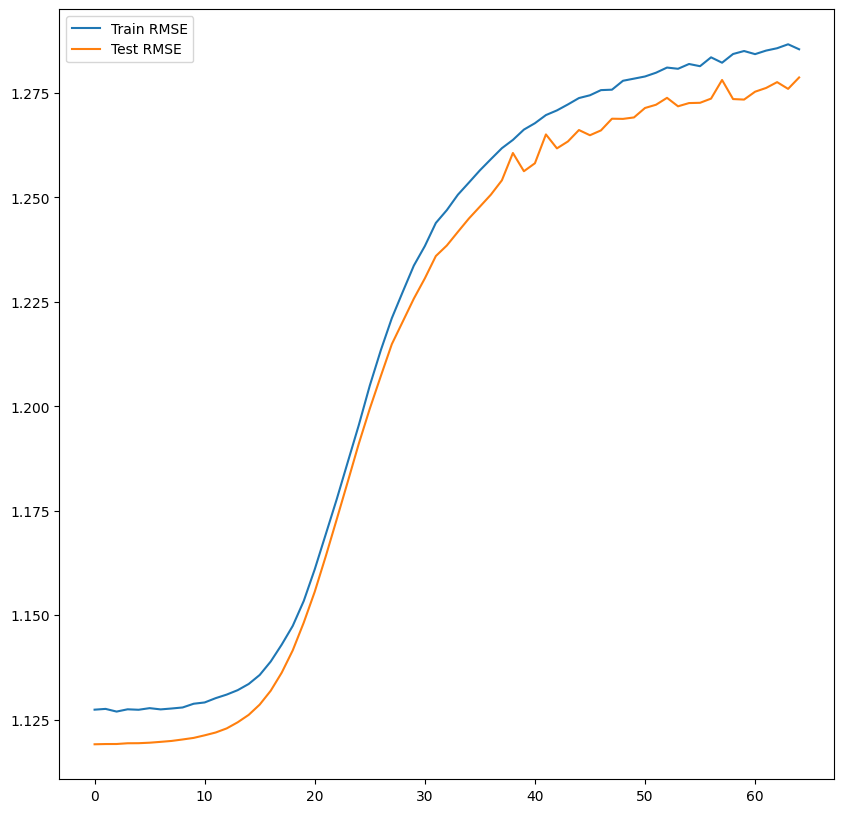

In [43]:
# Plot RMSE
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
plt.plot(result.history['rmse'],label="Train RMSE")
plt.plot(result.history['val_rmse'],label='Test RMSE')
plt.legend()
plt.show()